In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.6 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
import torch
print(torch.cuda.is_available())

True


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import kagglehub

path = kagglehub.dataset_download(
    "balraj98/deepglobe-land-cover-classification-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 2.74G/2.74G [02:30<00:00, 19.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2


In [10]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Files:", files[:5])
    print("-" * 50)

/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2
Files: ['metadata.csv', 'class_dict.csv']
--------------------------------------------------
/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/test
Files: ['780313_sat.jpg', '133160_sat.jpg', '977742_sat.jpg', '267766_sat.jpg', '8711_sat.jpg']
--------------------------------------------------
/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/train
Files: ['95683_sat.jpg', '430587_mask.png', '329017_sat.jpg', '866782_sat.jpg', '864488_sat.jpg']
--------------------------------------------------
/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/valid
Files: ['385534_sat.jpg', '525158_sat.jpg', '549550_sat.jpg', '621321_sat.jpg', '823133_sat.jpg']
--------------------------------------------------


In [11]:
import glob

sat_images = glob.glob(path + "/**/*_sat.*", recursive=True)

print("Total satellite images:", len(sat_images))
print(sat_images[:5])

Total satellite images: 1146
['/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/test/780313_sat.jpg', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/test/133160_sat.jpg', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/test/977742_sat.jpg', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/test/267766_sat.jpg', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/test/8711_sat.jpg']


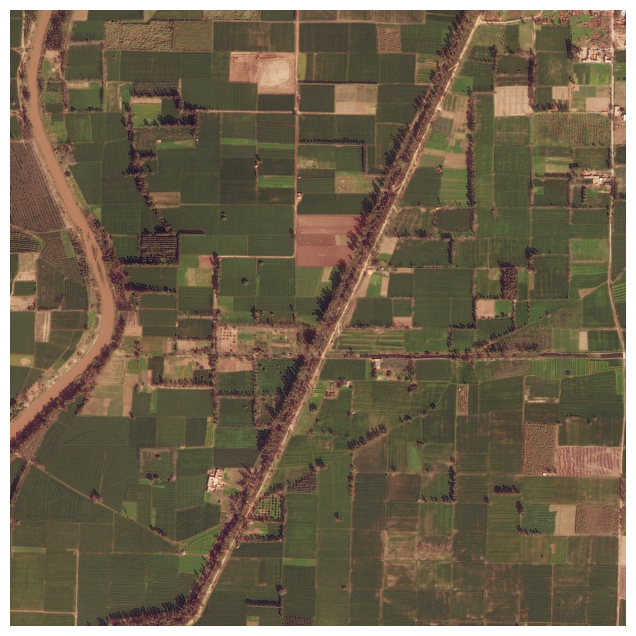

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(sat_images[0])

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

In [14]:
results = model.predict(
    source=sat_images[0],
    save=True,
    conf=0.25
)


image 1/1 /root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/test/780313_sat.jpg: 640x640 (no detections), 9.7ms
Speed: 10.4ms preprocess, 9.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict


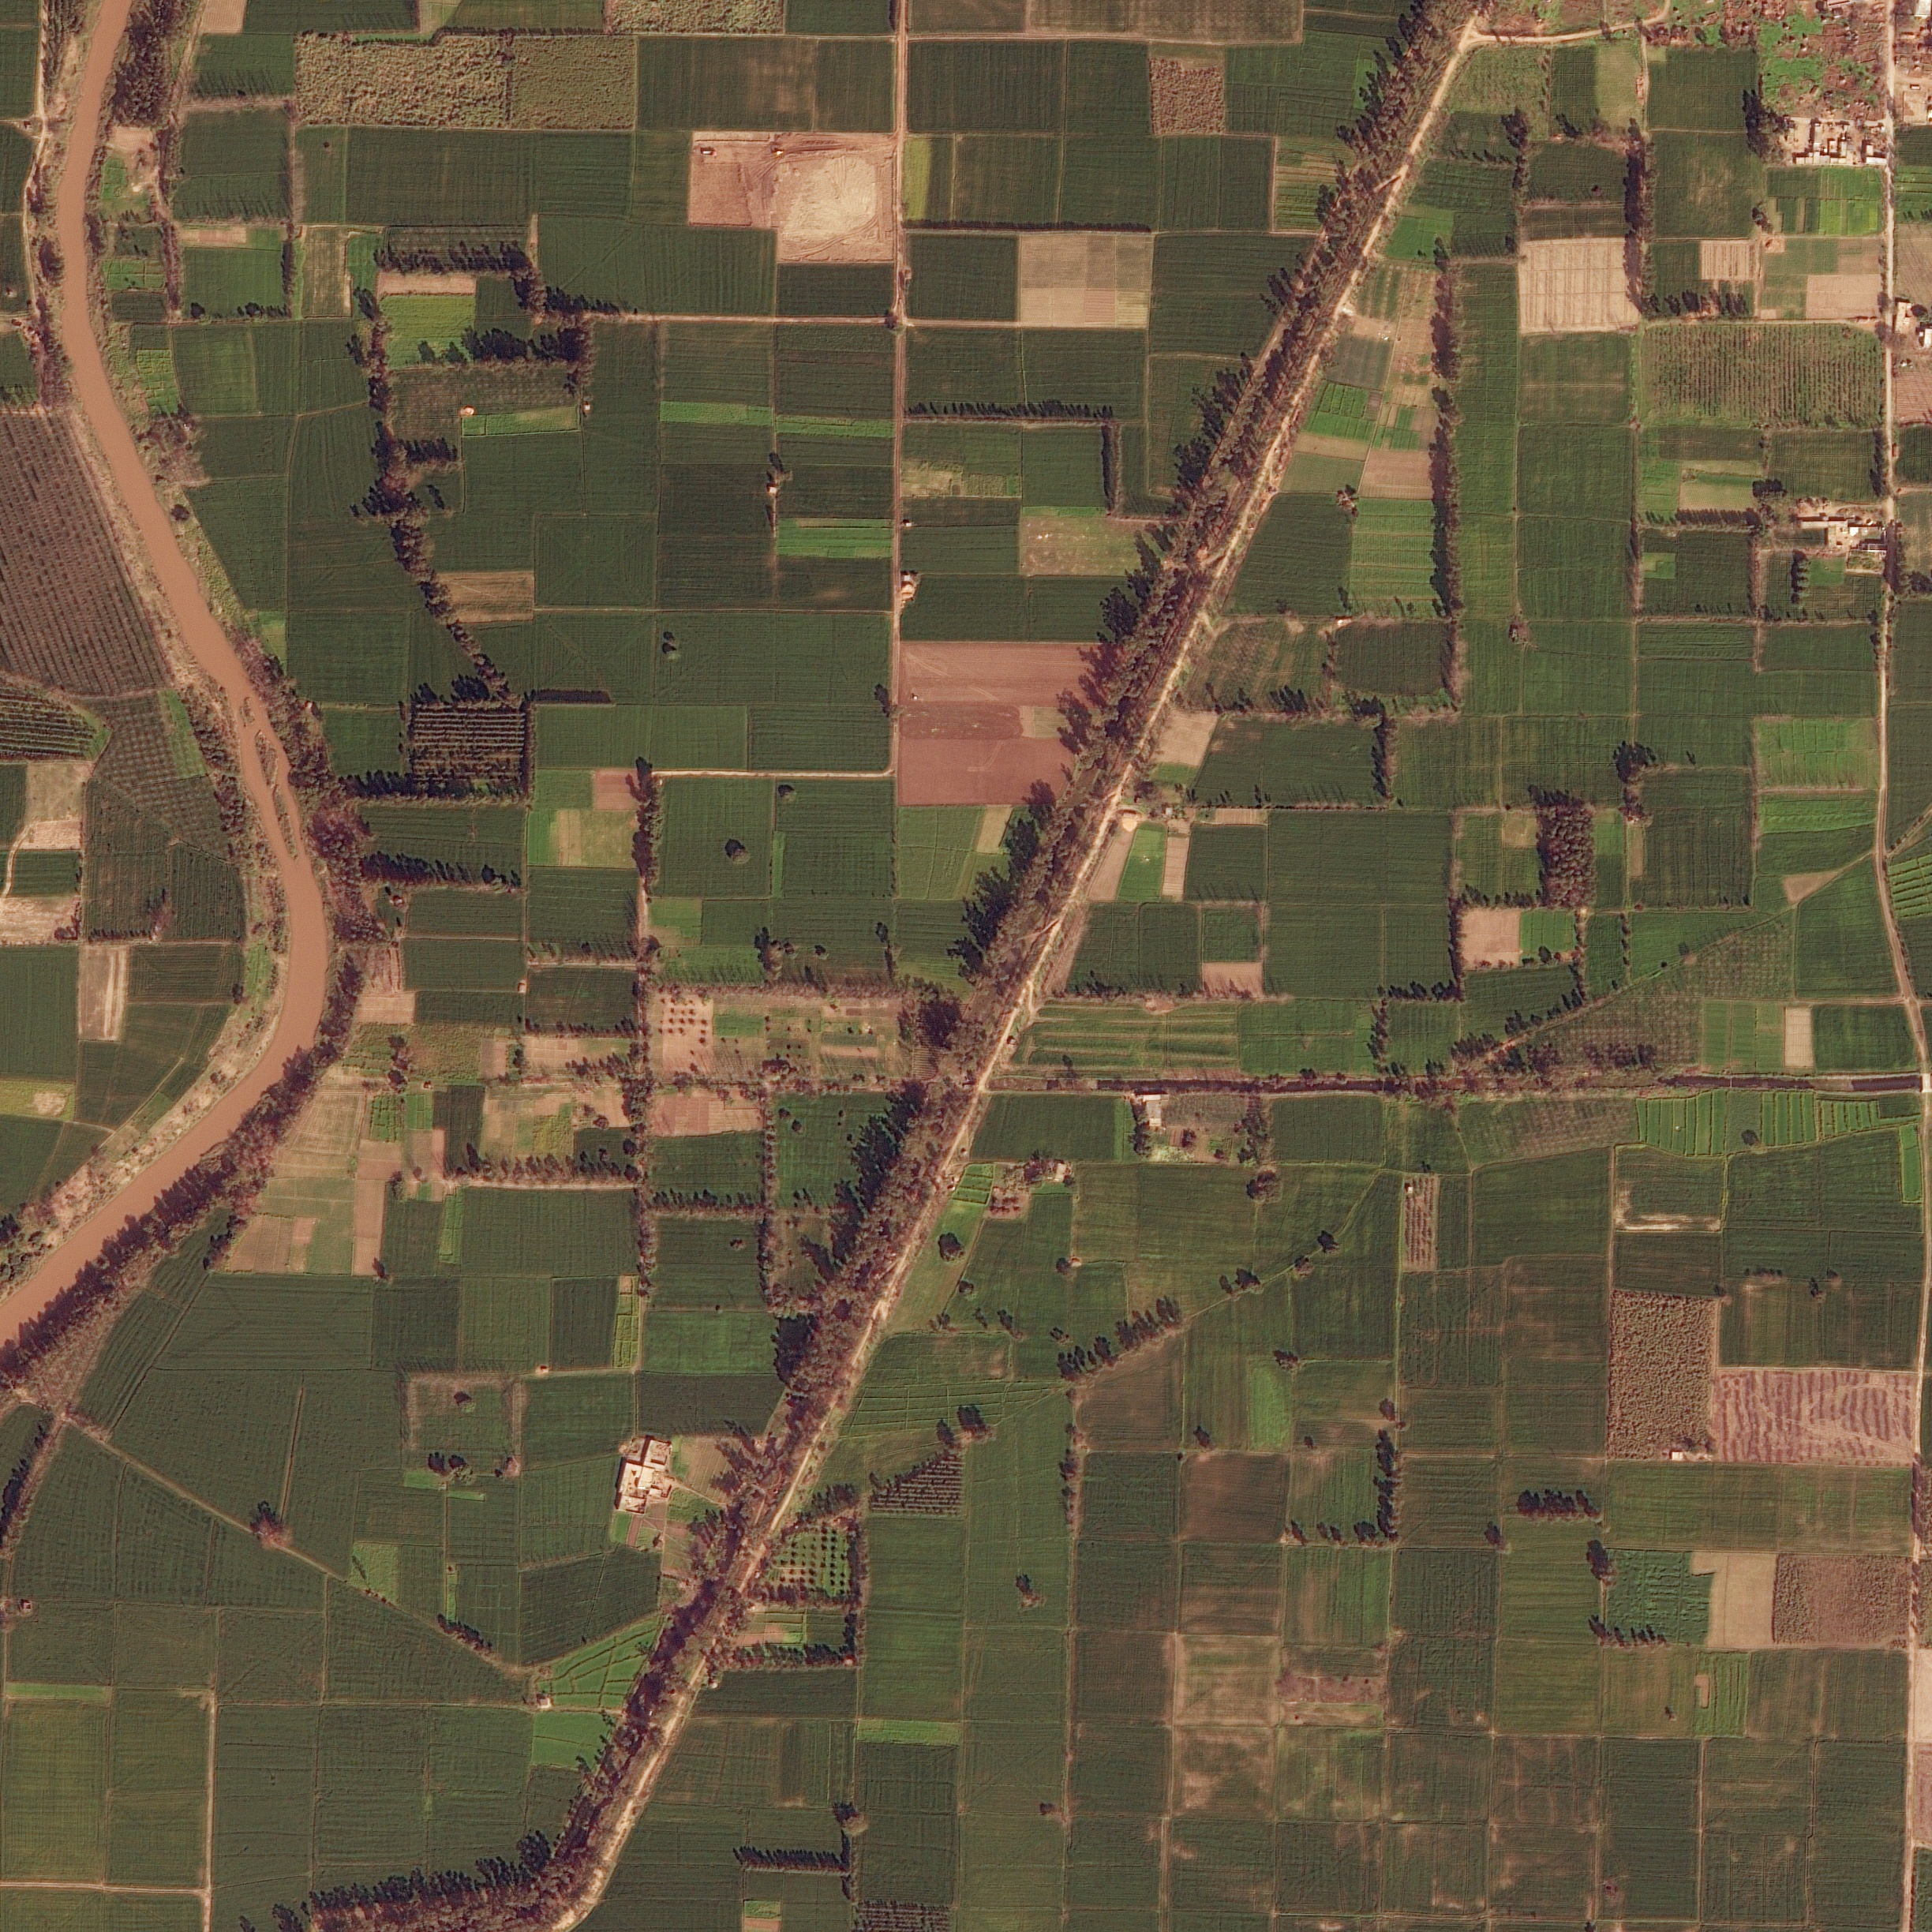

In [15]:
from IPython.display import Image as IPImage

IPImage(filename="runs/segment/predict/" + sat_images[0].split("/")[-1])

In [16]:
import pandas as pd

class_df = pd.read_csv(path + "/class_dict.csv")
print(class_df)

               name    r    g    b
0        urban_land    0  255  255
1  agriculture_land  255  255    0
2         rangeland  255    0  255
3       forest_land    0  255    0
4             water    0    0  255
5       barren_land  255  255  255
6           unknown    0    0    0


In [17]:
import glob

mask_images = glob.glob(path + "/**/*_mask.*", recursive=True)

print("Total mask images:", len(mask_images))
print(mask_images[:5])

Total mask images: 803
['/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/train/430587_mask.png', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/train/119_mask.png', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/train/786226_mask.png', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/train/654770_mask.png', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/train/802645_mask.png']


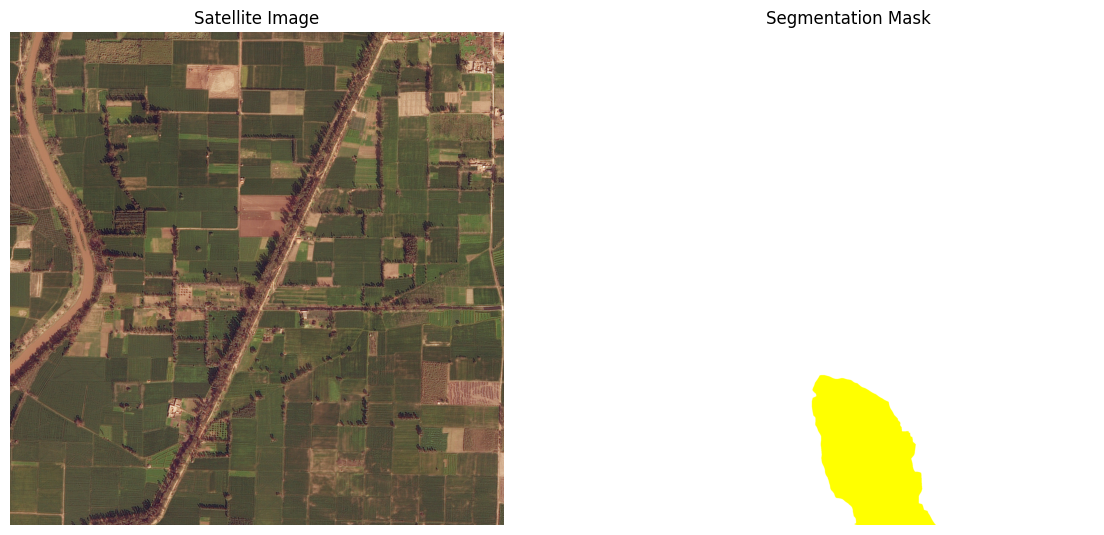

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

# Load first satellite image
sat = Image.open(sat_images[0])

# Load corresponding mask
mask = Image.open(mask_images[0])

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(sat)
ax[0].set_title("Satellite Image")
ax[0].axis("off")

ax[1].imshow(mask)
ax[1].set_title("Segmentation Mask")
ax[1].axis("off")

plt.show()

In [19]:
import os

# Build dictionary of masks using image ID
mask_dict = {}

for mask_path in mask_images:
    filename = os.path.basename(mask_path)

    # Extract ID before "_mask"
    image_id = filename.split("_mask")[0]

    mask_dict[image_id] = mask_path

# Build valid satellite-mask pairs
pairs = []

for sat_path in sat_images:
    filename = os.path.basename(sat_path)

    # Extract ID before "_sat"
    image_id = filename.split("_sat")[0]

    if image_id in mask_dict:
        pairs.append((sat_path, mask_dict[image_id]))

print("Total valid pairs:", len(pairs))
print(pairs[0])

Total valid pairs: 803
('/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/train/95683_sat.jpg', '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2/train/95683_mask.png')


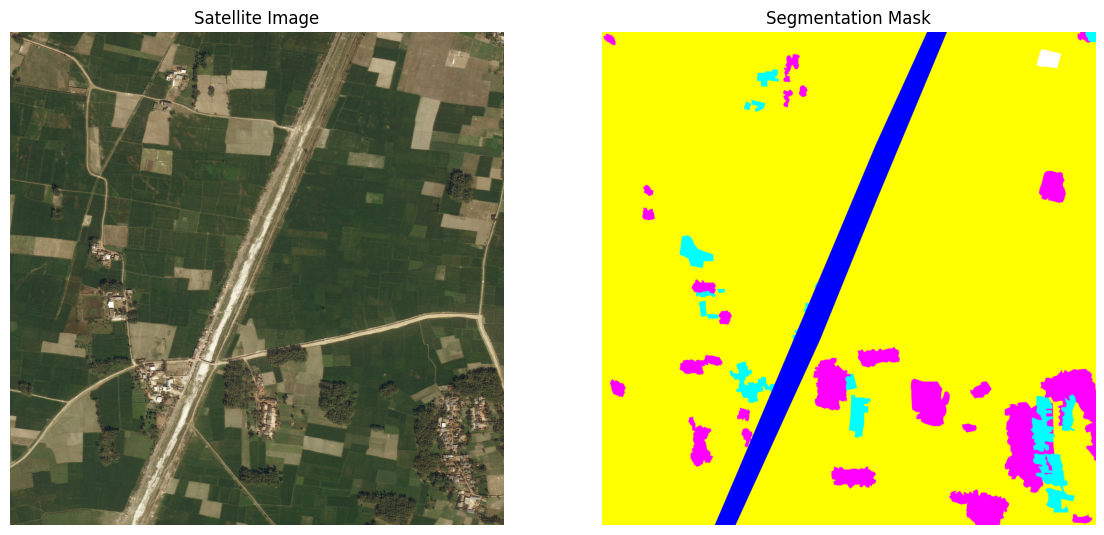

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

# Take first correct pair
sat_path, mask_path = pairs[0]

# Open images
sat = Image.open(sat_path)
mask = Image.open(mask_path)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(sat)
ax[0].set_title("Satellite Image")
ax[0].axis("off")

ax[1].imshow(mask)
ax[1].set_title("Segmentation Mask")
ax[1].axis("off")

plt.show()

In [21]:
import numpy as np

# RGB color to class ID mapping
COLOR_MAP = {
    (0, 255, 255): 0,      # urban_land
    (255, 255, 0): 1,      # agriculture_land
    (255, 0, 255): 2,      # rangeland
    (0, 255, 0): 3,        # forest_land
    (0, 0, 255): 4,        # water
    (255, 255, 255): 5,    # barren_land
    (0, 0, 0): 6           # unknown
}

print("Color map ready.")

Color map ready.


In [22]:
# Take first correct mask
_, mask_path = pairs[0]

# Load mask as numpy array
mask = np.array(Image.open(mask_path))

print("Mask shape:", mask.shape)

Mask shape: (2448, 2448, 3)


In [23]:
# Create empty class map
class_map = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)

# Convert RGB colors to class IDs
for rgb, class_id in COLOR_MAP.items():
    matches = np.all(mask == rgb, axis=-1)
    class_map[matches] = class_id

print("Conversion complete.")
print("Unique classes found:", np.unique(class_map))

Conversion complete.
Unique classes found: [0 1 2 4 5]


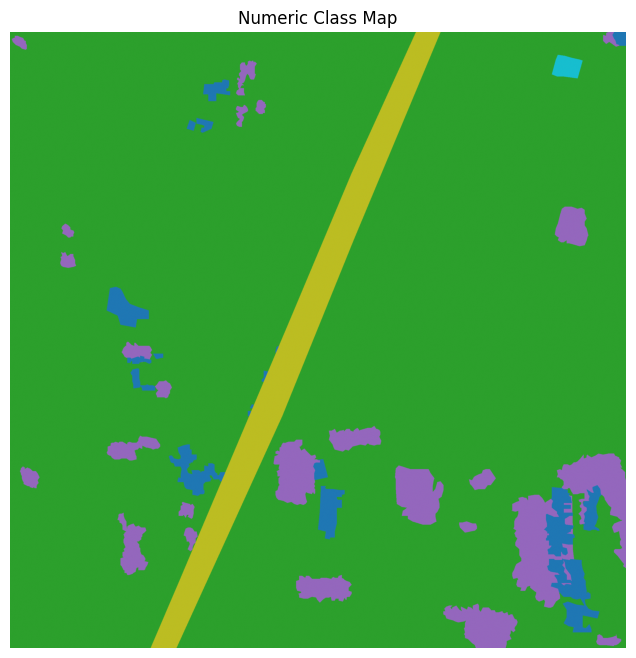

In [24]:
plt.figure(figsize=(8,8))

plt.imshow(class_map, cmap='tab10')

plt.title("Numeric Class Map")
plt.axis("off")

plt.show()

In [25]:
# Load satellite image
sat = np.array(Image.open(sat_path))

print("Satellite image shape:", sat.shape)

Satellite image shape: (2448, 2448, 3)


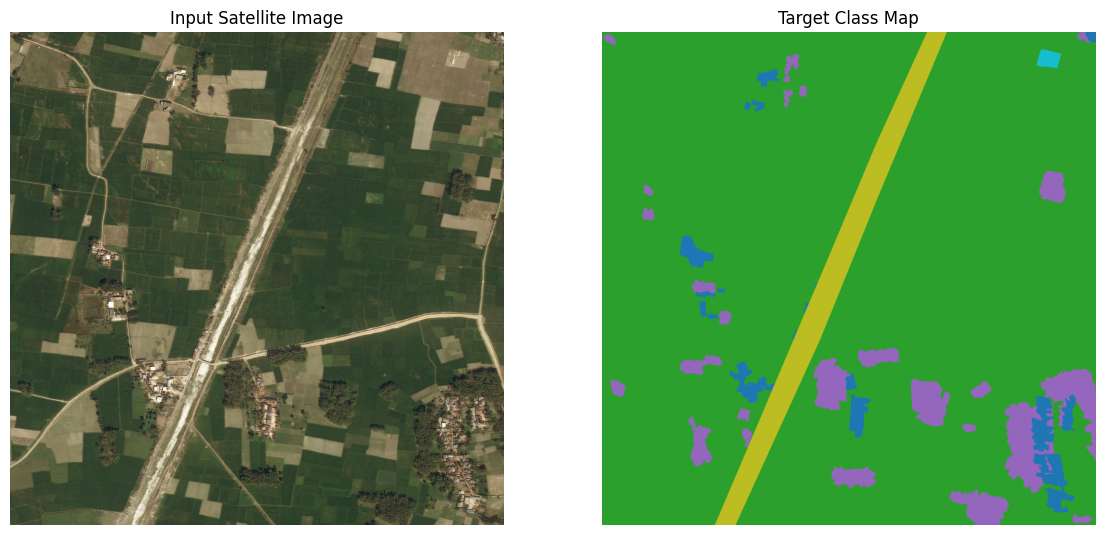

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14,7))

ax[0].imshow(sat)
ax[0].set_title("Input Satellite Image")
ax[0].axis("off")

ax[1].imshow(class_map, cmap='tab10')
ax[1].set_title("Target Class Map")
ax[1].axis("off")

plt.show()

In [28]:
from torch.utils.data import Dataset
import torch

class DeepGlobeDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        sat_path, mask_path = self.pairs[idx]

        # Load satellite image
        image = np.array(Image.open(sat_path).convert("RGB"))

        # Load mask
        mask = np.array(Image.open(mask_path).convert("RGB"))

        # Create empty class map
        class_map = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)

        # Convert RGB mask to class IDs
        for rgb, class_id in COLOR_MAP.items():
            matches = np.all(mask == rgb, axis=-1)
            class_map[matches] = class_id

        # Convert to tensors
        image = torch.tensor(image).permute(2,0,1).float() / 255.0
        class_map = torch.tensor(class_map).long()

        return image, class_map

In [29]:
dataset = DeepGlobeDataset(pairs)

print("Dataset size:", len(dataset))

Dataset size: 803


In [30]:
image, mask = dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image shape: torch.Size([3, 2448, 2448])
Mask shape: torch.Size([2448, 2448])


In [31]:
from torchvision.transforms import functional as TF

class DeepGlobeDataset(Dataset):

    def __init__(self, pairs, size=(512, 512)):
        self.pairs = pairs
        self.size = size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        sat_path, mask_path = self.pairs[idx]

        # Load image
        image = Image.open(sat_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")

        # Resize
        image = image.resize(self.size)
        mask = mask.resize(self.size)

        # Convert to numpy
        image = np.array(image)
        mask = np.array(mask)

        # Create class map
        class_map = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)

        for rgb, class_id in COLOR_MAP.items():
            matches = np.all(mask == rgb, axis=-1)
            class_map[matches] = class_id

        # Convert to tensors
        image = torch.tensor(image).permute(2,0,1).float() / 255.0
        class_map = torch.tensor(class_map).long()

        return image, class_map

In [32]:
dataset = DeepGlobeDataset(pairs)

image, mask = dataset[0]

print(image.shape)
print(mask.shape)

torch.Size([3, 512, 512])
torch.Size([512, 512])


In [33]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

print("DataLoader ready.")

DataLoader ready.


In [34]:
images, masks = next(iter(dataloader))

print("Batch image shape:", images.shape)
print("Batch mask shape:", masks.shape)

Batch image shape: torch.Size([2, 3, 512, 512])
Batch mask shape: torch.Size([2, 512, 512])


In [35]:
!pip install transformers

In [36]:
from transformers import SegformerForSemanticSegmentation

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=7,
    ignore_mismatched_sizes=True
)

print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([7, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded.


In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

print("Using device:", device)

Using device: cuda


In [38]:
images, masks = next(iter(dataloader))

images = images.to(device)
masks = masks.to(device)

outputs = model(
    pixel_values=images,
    labels=masks
)

print("Loss:", outputs.loss.item())
print("Logits shape:", outputs.logits.shape)

Loss: 1.9701186418533325
Logits shape: torch.Size([2, 7, 128, 128])


In [39]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5
)

print("Optimizer ready.")

Optimizer ready.


In [40]:
from tqdm import tqdm

model.train()

EPOCHS = 3

for epoch in range(EPOCHS):

    total_loss = 0

    progress_bar = tqdm(dataloader)

    for images, masks in progress_bar:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=images,
            labels=masks
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_description(
            f"Epoch {epoch+1} Loss: {loss.item():.4f}"
        )

    avg_loss = total_loss / len(dataloader)

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}")

Epoch 1 Loss: 0.7548: 100%|██████████| 402/402 [05:03<00:00,  1.32it/s]



Epoch 1 Average Loss: 1.2978


Epoch 2 Loss: 0.5438: 100%|██████████| 402/402 [04:58<00:00,  1.35it/s]



Epoch 2 Average Loss: 0.9102


Epoch 3 Loss: 1.8795: 100%|██████████| 402/402 [04:58<00:00,  1.35it/s]


Epoch 3 Average Loss: 0.7799


In [41]:
model.eval()

print("Evaluation mode enabled.")

Evaluation mode enabled.


In [42]:
image, true_mask = dataset[0]

print(image.shape)
print(true_mask.shape)

torch.Size([3, 512, 512])
torch.Size([512, 512])


In [43]:
with torch.no_grad():

    input_tensor = image.unsqueeze(0).to(device)

    outputs = model(pixel_values=input_tensor)

    predicted_mask = outputs.logits.argmax(dim=1)

predicted_mask = predicted_mask.cpu().numpy()[0]

print("Prediction shape:", predicted_mask.shape)

Prediction shape: (128, 128)


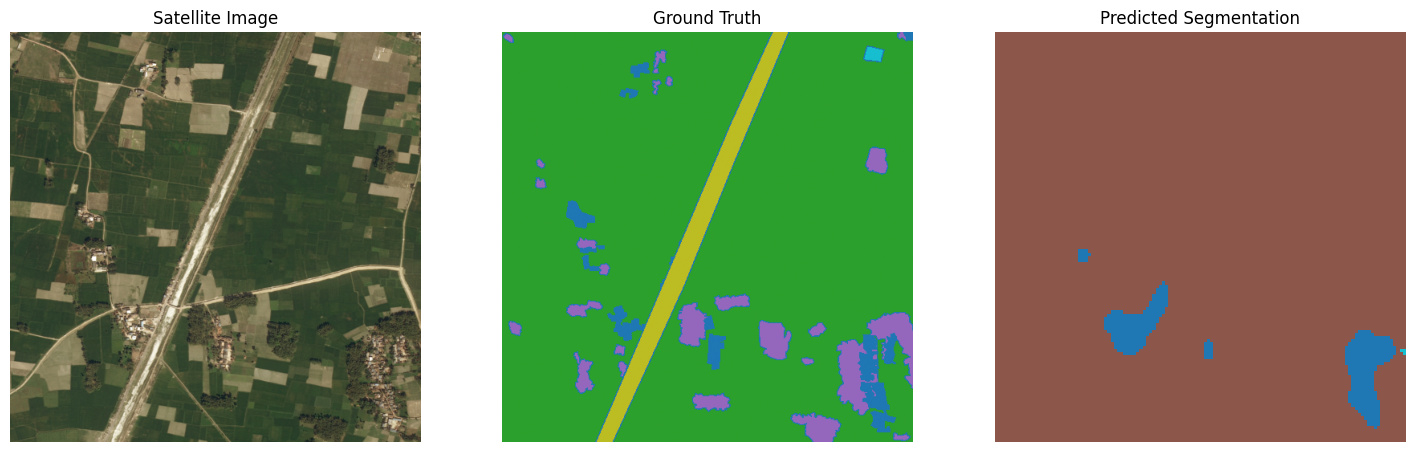

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))

# Original satellite image
ax[0].imshow(image.permute(1,2,0))
ax[0].set_title("Satellite Image")
ax[0].axis("off")

# Ground truth mask
ax[1].imshow(true_mask, cmap='tab10')
ax[1].set_title("Ground Truth")
ax[1].axis("off")

# Predicted segmentation
ax[2].imshow(predicted_mask, cmap='tab10')
ax[2].set_title("Predicted Segmentation")
ax[2].axis("off")

plt.show()

In [45]:
# Class ID to RGB color
ID_TO_COLOR = {
    0: (0, 255, 255),      # urban_land
    1: (255, 255, 0),      # agriculture_land
    2: (255, 0, 255),      # rangeland
    3: (0, 255, 0),        # forest_land
    4: (0, 0, 255),        # water
    5: (255, 255, 255),    # barren_land
    6: (0, 0, 0)           # unknown
}

In [46]:
# Create empty RGB image
pred_rgb = np.zeros((predicted_mask.shape[0],
                     predicted_mask.shape[1],
                     3), dtype=np.uint8)

# Paint each class with proper color
for class_id, color in ID_TO_COLOR.items():
    pred_rgb[predicted_mask == class_id] = color

print("RGB prediction created.")

RGB prediction created.


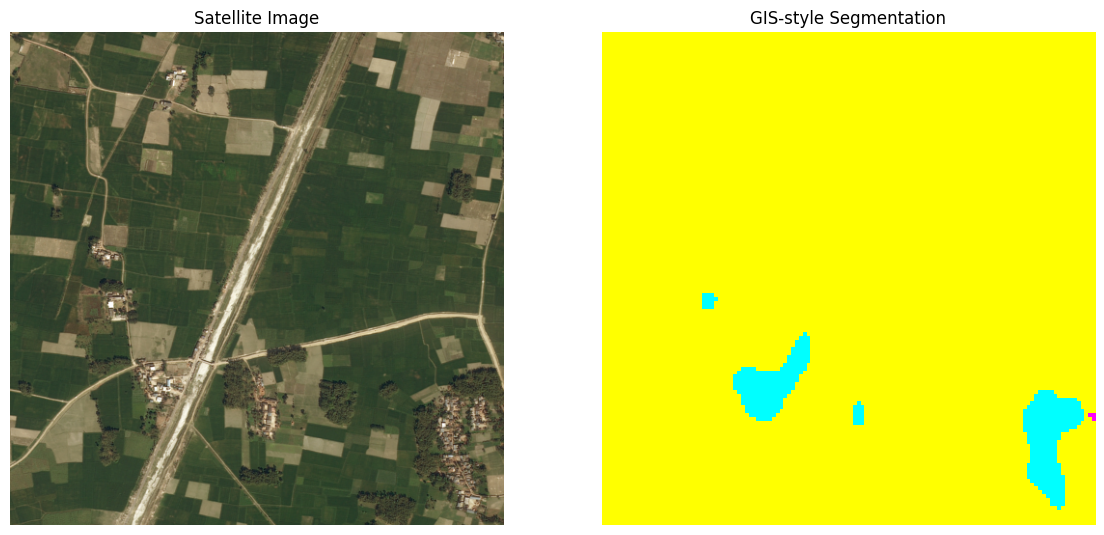

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(14,7))

# Original image
ax[0].imshow(image.permute(1,2,0))
ax[0].set_title("Satellite Image")
ax[0].axis("off")

# GIS-style prediction
ax[1].imshow(pred_rgb)
ax[1].set_title("GIS-style Segmentation")
ax[1].axis("off")

plt.show()

In [48]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, masks in dataloader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(pixel_values=images)

        preds = outputs.logits.argmax(dim=1)

        # Resize predictions to mask size
        preds = torch.nn.functional.interpolate(
            preds.unsqueeze(1).float(),
            size=masks.shape[-2:],
            mode='nearest'
        ).squeeze(1).long()

        correct += (preds == masks).sum().item()
        total += masks.numel()

accuracy = correct / total

print(f"Pixel Accuracy: {accuracy:.4f}")

Pixel Accuracy: 0.8379


In [49]:
CLASS_NAMES = {
    0: "urban_land",
    1: "agriculture_land",
    2: "rangeland",
    3: "forest_land",
    4: "water",
    5: "barren_land",
    6: "unknown"
}

In [50]:
import json

# Count pixels per class
unique, counts = np.unique(predicted_mask, return_counts=True)

total_pixels = predicted_mask.size

results = {}

for class_id, count in zip(unique, counts):

    class_name = CLASS_NAMES[int(class_id)]

    coverage_percent = (count / total_pixels) * 100

    results[class_name] = {
        "pixel_count": int(count),
        "coverage_percent": round(float(coverage_percent), 2)
    }

# Save JSON
with open("segmentation_results.json", "w") as f:
    json.dump(results, f, indent=4)

print(json.dumps(results, indent=4))

{
    "urban_land": {
        "pixel_count": 520,
        "coverage_percent": 3.17
    },
    "agriculture_land": {
        "pixel_count": 15861,
        "coverage_percent": 96.81
    },
    "rangeland": {
        "pixel_count": 3,
        "coverage_percent": 0.02
    }
}


In [51]:
import json
import numpy as np

# -----------------------------------
# Assumed Ground Sampling Distance
# -----------------------------------
# 1 pixel ≈ 0.5m
GSD_METERS = 0.5

# Area represented by one pixel
PIXEL_AREA_SQ_M = GSD_METERS * GSD_METERS

# -----------------------------------
# Class Names
# -----------------------------------
CLASS_NAMES = {
    0: "Urban Land",
    1: "Agricultural Land",
    2: "Open/Rangeland",
    3: "Forest & Green Cover",
    4: "Water Bodies",
    5: "Barren Land",
    6: "Unknown"
}

# -----------------------------------
# Human-readable descriptions
# -----------------------------------
STATUS_MESSAGES = {
    "Urban Land": "Built-up or developed regions detected",
    "Agricultural Land": "Agricultural activity zones identified",
    "Open/Rangeland": "Open land or sparse vegetation identified",
    "Forest & Green Cover": "Green cover and vegetation detected",
    "Water Bodies": "Water resource regions identified",
    "Barren Land": "Low vegetation or unused land identified",
    "Unknown": "Unclassified terrain detected"
}

# -----------------------------------
# Compute statistics
# -----------------------------------
unique, counts = np.unique(predicted_mask, return_counts=True)

total_pixels = predicted_mask.size

results = []

for class_id, count in zip(unique, counts):

    class_name = CLASS_NAMES[int(class_id)]

    coverage_percent = (count / total_pixels) * 100

    estimated_area = count * PIXEL_AREA_SQ_M

    results.append({
        "asset_type": class_name,
        "estimated_area_sq_m": round(float(estimated_area), 2),
        "coverage_percent": round(float(coverage_percent), 2),
        "status": STATUS_MESSAGES[class_name]
    })

# -----------------------------------
# Final structured report
# -----------------------------------
final_report = {
    "report_type": "Spatial Asset Analysis",
    "model": "SegFormer-B0 Semantic Segmentation",
    "assumed_gsd_m_per_pixel": GSD_METERS,
    "total_image_area_sq_m": round(float(total_pixels * PIXEL_AREA_SQ_M), 2),
    "detected_assets": results
}

# -----------------------------------
# Save JSON
# -----------------------------------
with open("spatial_asset_report.json", "w") as f:
    json.dump(final_report, f, indent=4)

# -----------------------------------
# Preview report
# -----------------------------------
print(json.dumps(final_report, indent=4))

{
    "report_type": "Spatial Asset Analysis",
    "model": "SegFormer-B0 Semantic Segmentation",
    "assumed_gsd_m_per_pixel": 0.5,
    "total_image_area_sq_m": 4096.0,
    "detected_assets": [
        {
            "asset_type": "Urban Land",
            "estimated_area_sq_m": 130.0,
            "coverage_percent": 3.17,
            "status": "Built-up or developed regions detected"
        },
        {
            "asset_type": "Agricultural Land",
            "estimated_area_sq_m": 3965.25,
            "coverage_percent": 96.81,
            "status": "Agricultural activity zones identified"
        },
        {
            "asset_type": "Open/Rangeland",
            "estimated_area_sq_m": 0.75,
            "coverage_percent": 0.02,
            "status": "Open land or sparse vegetation identified"
        }
    ]
}


In [52]:
# -----------------------------------
# Spatial Intelligence Rules
# -----------------------------------

alerts = []

# Convert results into quick lookup
coverage_map = {}

for asset in final_report["detected_assets"]:
    coverage_map[asset["asset_type"]] = asset["coverage_percent"]

urban = coverage_map.get("Urban Land", 0)
green = coverage_map.get("Forest & Green Cover", 0)
water = coverage_map.get("Water Bodies", 0)
open_land = coverage_map.get("Open/Rangeland", 0)

# -----------------------------------
# Urban congestion detection
# -----------------------------------
if urban > 45 and green < 15:
    alerts.append({
        "alert": "Urban Heat Island Risk",
        "severity": "High",
        "description": "Dense urban coverage with insufficient green cover detected."
    })

# -----------------------------------
# Green deficiency detection
# -----------------------------------
if green < 10:
    alerts.append({
        "alert": "Green Cover Deficiency",
        "severity": "Medium",
        "description": "Low vegetation coverage detected. Urban plantation or park development recommended."
    })

# -----------------------------------
# Flood proximity heuristic
# -----------------------------------
if water > 20 and urban > 25:
    alerts.append({
        "alert": "Potential Flood Vulnerability",
        "severity": "Medium",
        "description": "Large water-body presence near urban regions may increase flood/submergence risk."
    })

# -----------------------------------
# Open land recommendation
# -----------------------------------
if open_land > 30 and green < 15:
    alerts.append({
        "alert": "Urban Planning Opportunity",
        "severity": "Low",
        "description": "Open land suitable for green-zone or recreational park development detected."
    })

# -----------------------------------
# Add alerts to final report
# -----------------------------------
final_report["spatial_alerts"] = alerts

# Save updated report
with open("smart_spatial_report.json", "w") as f:
    json.dump(final_report, f, indent=4)

# Preview
print(json.dumps(final_report, indent=4))

{
    "report_type": "Spatial Asset Analysis",
    "model": "SegFormer-B0 Semantic Segmentation",
    "assumed_gsd_m_per_pixel": 0.5,
    "total_image_area_sq_m": 4096.0,
    "detected_assets": [
        {
            "asset_type": "Urban Land",
            "estimated_area_sq_m": 130.0,
            "coverage_percent": 3.17,
            "status": "Built-up or developed regions detected"
        },
        {
            "asset_type": "Agricultural Land",
            "estimated_area_sq_m": 3965.25,
            "coverage_percent": 96.81,
            "status": "Agricultural activity zones identified"
        },
        {
            "asset_type": "Open/Rangeland",
            "estimated_area_sq_m": 0.75,
            "coverage_percent": 0.02,
            "status": "Open land or sparse vegetation identified"
        }
    ],
    "spatial_alerts": [
        {
            "alert": "Green Cover Deficiency",
            "severity": "Medium",
            "description": "Low vegetation coverage det

In [53]:
torch.save(model.state_dict(), "segformer_spatial_model.pth")

print("Model saved successfully.")

Model saved successfully.


In [54]:
from google.colab import files

files.download("segformer_spatial_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
def predict_image(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")
    original_size = image.size

    # Resize for model
    resized = image.resize((512, 512))

    # Convert to tensor
    tensor = torch.tensor(np.array(resized)) \
        .permute(2,0,1) \
        .float() / 255.0

    tensor = tensor.unsqueeze(0).to(device)

    # Predict
    model.eval()

    with torch.no_grad():

        outputs = model(pixel_values=tensor)

        pred_mask = outputs.logits.argmax(dim=1)

    pred_mask = pred_mask.cpu().numpy()[0]

    return pred_mask, original_size

In [56]:
test_image = pairs[0][0]

pred_mask, original_size = predict_image(test_image)

print(pred_mask.shape)
print(original_size)

(128, 128)
(2448, 2448)


In [57]:
from transformers import SegformerForSemanticSegmentation

deployment_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=7,
    ignore_mismatched_sizes=True
)

deployment_model.load_state_dict(
    torch.load("segformer_spatial_model.pth", map_location=device)
)

deployment_model.to(device)

deployment_model.eval()

print("Deployment model loaded successfully.")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([7, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Deployment model loaded successfully.


In [58]:
def deployment_predict(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize for model
    resized = image.resize((512, 512))

    # Convert to numpy
    image_np = np.array(resized)

    # Tensor conversion
    tensor = torch.tensor(image_np) \
        .permute(2,0,1) \
        .float() / 255.0

    tensor = tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():

        outputs = deployment_model(pixel_values=tensor)

        pred_mask = outputs.logits.argmax(dim=1)

    pred_mask = pred_mask.cpu().numpy()[0]

    return pred_mask

In [59]:
test_image = pairs[0][0]

pred_mask = deployment_predict(test_image)

print(pred_mask.shape)

(128, 128)


In [60]:
def create_overlay(image_path, pred_mask):

    # Original image
    image = Image.open(image_path).convert("RGB")
    image = image.resize((128, 128))

    image_np = np.array(image)

    # Create RGB segmentation mask
    seg_rgb = np.zeros((128, 128, 3), dtype=np.uint8)

    for class_id, color in ID_TO_COLOR.items():
        seg_rgb[pred_mask == class_id] = color

    # Blend overlay
    overlay = (
        0.6 * image_np +
        0.4 * seg_rgb
    ).astype(np.uint8)

    return overlay

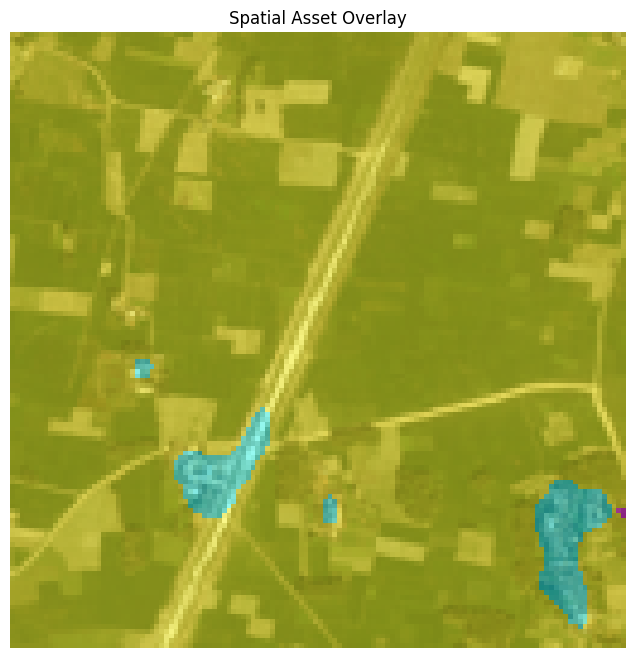

In [61]:
overlay = create_overlay(test_image, pred_mask)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.title("Spatial Asset Overlay")
plt.axis("off")
plt.show()